# DPT Bone Marrow — λ_vf Sweep Plotting

Data extracted from the completed HPC run `dpt_bone_marrow_vf_sweep_20260523_200612`.  
All 5 seeds completed fully.  
λ_lap fixed at 1. λ_vf swept over 6 values: `np.logspace(1.5, 4.0, 6)`.  
Epochs logged every 10 steps; epoch 140 used as proxy for epoch 150 (final).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# λ_vf values — np.logspace(1.5, 4.0, 6)
LAMBDA_VFS = np.logspace(1.5, 4.0, 6)
print('lambda_vf values:', np.round(LAMBDA_VFS, 4))

lambda_vf values: [   31.6228   100.       316.2278  1000.      3162.2777 10000.    ]


In [3]:
# ---------------------------------------------------------------------------
# Raw data: r values logged every 10 epochs (i=0,10,...,140)
# Shape: [seed, lambda_idx, epoch_idx]  where epoch_idx ∈ {0,...,14} → epochs 0,10,...,140
# All 5 seeds × 6 lambda values × 15 logged checkpoints — no missing data
# ---------------------------------------------------------------------------

EPOCHS_LOGGED = list(range(0, 141, 10))  # 0, 10, ..., 140

# Each row = one lambda_vf, each column = one logged epoch
seed1 = np.array([
    # lv=31.62
    [0.246, 0.837, 0.703, 0.776, 0.798, 0.783, 0.832, 0.869, 0.881, 0.885, 0.886, 0.887, 0.888, 0.889, 0.889],
    # lv=100
    [0.239, 0.582, 0.754, 0.823, 0.846, 0.826, 0.847, 0.849, 0.844, 0.839, 0.833, 0.822, 0.810, 0.790, 0.773],
    # lv=316.2
    [0.260, 0.542, 0.502, 0.538, 0.603, 0.679, 0.717, 0.733, 0.741, 0.749, 0.753, 0.754, 0.751, 0.749, 0.741],
    # lv=1000
    [0.572, 0.732, 0.837, 0.800, 0.855, 0.883, 0.880, 0.903, 0.897, 0.879, 0.819, 0.732, 0.465, 0.693, 0.333],
    # lv=3162
    [0.378, 0.751, 0.795, 0.784, 0.777, 0.773, 0.752, 0.726, 0.825, 0.450, -0.030, -0.074, 0.217, 0.259, 0.317],
    # lv=10000
    [0.321, 0.723, 0.711, 0.458, 0.272, 0.144, 0.269, -0.028, 0.040, 0.061, 0.142, 0.058, -0.085, -0.168, -0.196],
])

seed2 = np.array([
    # lv=31.62
    [0.222, 0.535, 0.535, 0.587, 0.684, 0.716, 0.696, 0.665, 0.642, 0.626, 0.621, 0.618, 0.615, 0.620, 0.623],
    # lv=100
    [0.618, 0.631, 0.736, 0.721, 0.735, 0.748, 0.782, 0.828, 0.838, 0.844, 0.854, 0.860, 0.864, 0.866, 0.863],
    # lv=316.2
    [0.484, 0.705, 0.851, 0.910, 0.942, 0.950, 0.935, 0.925, 0.913, 0.902, 0.901, 0.904, 0.907, 0.911, 0.915],
    # lv=1000
    [0.632, 0.660, 0.637, 0.627, 0.633, 0.621, 0.586, 0.691, 0.578, 0.249, -0.163, 0.482, 0.179, 0.086, 0.319],
    # lv=3162
    [0.481, 0.821, 0.791, 0.822, 0.836, 0.756, 0.479, 0.009, 0.079, 0.094, -0.100, -0.063, -0.089, -0.088, -0.088],
    # lv=10000
    [0.600, 0.761, 0.865, 0.662, 0.193, 0.331, 0.288, 0.150, 0.111, 0.087, 0.001, 0.022, 0.100, 0.096, 0.071],
])

seed3 = np.array([
    # lv=31.62
    [0.475, 0.631, 0.599, 0.595, 0.649, 0.678, 0.703, 0.714, 0.727, 0.744, 0.759, 0.769, 0.776, 0.783, 0.787],
    # lv=100
    [0.296, 0.612, 0.578, 0.620, 0.548, 0.579, 0.573, 0.571, 0.582, 0.586, 0.584, 0.575, 0.582, 0.584, 0.577],
    # lv=316.2
    [0.517, 0.805, 0.855, 0.763, 0.858, 0.885, 0.854, 0.863, 0.871, 0.861, 0.864, 0.857, 0.855, 0.848, 0.844],
    # lv=1000
    [0.323, 0.765, 0.885, 0.881, 0.884, 0.878, 0.877, 0.840, 0.683, 0.624, 0.550, 0.409, 0.286, 0.087, 0.195],
    # lv=3162
    [0.346, 0.578, 0.531, 0.516, 0.502, 0.409, 0.359, -0.022, 0.201, 0.140, 0.357, 0.334, 0.270, 0.111, 0.110],
    # lv=10000
    [0.363, 0.602, 0.694, 0.728, 0.749, 0.818, 0.684, 0.070, 0.252, 0.277, 0.282, 0.224, 0.197, 0.362, 0.200],
])

seed4 = np.array([
    # lv=31.62
    [0.527, 0.594, 0.703, 0.759, 0.772, 0.773, 0.768, 0.760, 0.756, 0.753, 0.749, 0.744, 0.740, 0.735, 0.728],
    # lv=100
    [0.324, 0.658, 0.669, 0.675, 0.658, 0.675, 0.669, 0.670, 0.661, 0.712, 0.711, 0.709, 0.706, 0.703, 0.701],
    # lv=316.2
    [0.299, 0.449, 0.672, 0.734, 0.796, 0.786, 0.807, 0.810, 0.807, 0.808, 0.809, 0.806, 0.803, 0.823, 0.822],
    # lv=1000
    [0.404, 0.651, 0.668, 0.616, 0.587, 0.588, 0.613, 0.636, 0.642, 0.642, 0.634, 0.656, 0.219, 0.226, 0.038],
    # lv=3162
    [0.291, 0.683, 0.677, 0.643, 0.619, 0.629, 0.644, 0.564, 0.568, 0.270, 0.233, 0.056, 0.080, 0.078, 0.236],
    # lv=10000
    [0.484, 0.667, 0.718, 0.760, 0.729, 0.504, 0.452, -0.088, 0.184, 0.135, 0.206, 0.187, 0.136, 0.168, 0.133],
])

seed5 = np.array([
    # lv=31.62
    [0.201, 0.742, 0.745, 0.756, 0.756, 0.751, 0.749, 0.749, 0.756, 0.758, 0.756, 0.752, 0.744, 0.736, 0.732],
    # lv=100
    [0.303, 0.421, 0.645, 0.639, 0.655, 0.655, 0.652, 0.659, 0.670, 0.681, 0.688, 0.693, 0.697, 0.699, 0.702],
    # lv=316.2
    [0.650, 0.716, 0.766, 0.879, 0.871, 0.845, 0.856, 0.869, 0.889, 0.880, 0.861, 0.844, 0.458, 0.308, 0.279],
    # lv=1000
    [0.367, 0.699, 0.766, 0.855, 0.885, 0.910, 0.919, 0.917, 0.905, 0.924, 0.899, 0.611, 0.207, -0.096, 0.006],
    # lv=3162
    [0.544, 0.523, 0.625, 0.696, 0.718, 0.727, 0.747, 0.643, 0.425, 0.418, 0.212, 0.108, 0.044, 0.040, 0.077],
    # lv=10000
    [0.139, 0.802, 0.878, 0.897, 0.894, 0.882, 0.857, 0.728, 0.337, 0.042, 0.555, 0.262, 0.269, 0.243, 0.248],
])

# Stack: shape (5, 6, 15)  — seeds × lambdas × logged_epochs
all_seeds = np.stack([seed1, seed2, seed3, seed4, seed5], axis=0)
print('all_seeds shape:', all_seeds.shape)  # (5, 6, 15)

all_seeds shape: (5, 6, 15)


In [4]:
# ---------------------------------------------------------------------------
# Summary: r at epoch ~50 (idx 5), ~100 (idx 10), ~140 (idx 14)
# Using logged epochs 50, 100, 140 as proxies for script checkpoints 50, 100, 150
# ---------------------------------------------------------------------------

EPOCH_IDX = {'~50': 5, '~100': 10, '~140': 14}

summary = {}
for label, eidx in EPOCH_IDX.items():
    vals = all_seeds[:, :, eidx]  # (5, 6)
    summary[label] = {
        'mean': np.nanmean(vals, axis=0),
        'std':  np.nanstd(vals, axis=0),
        'per_seed': vals,
    }

df_summary = pd.DataFrame({
    'lambda_vf': LAMBDA_VFS,
    'ep50_mean':  summary['~50']['mean'],
    'ep50_std':   summary['~50']['std'],
    'ep100_mean': summary['~100']['mean'],
    'ep100_std':  summary['~100']['std'],
    'ep140_mean': summary['~140']['mean'],
    'ep140_std':  summary['~140']['std'],
})
df_summary

,lambda_vf,ep50_mean,ep50_std,ep100_mean,ep100_std,ep140_mean,ep140_std
0,31.622777,0.7402,0.038675,0.7542,0.083865,0.7518,0.086730
1,100.000000,0.6966,0.084158,0.7340,0.099344,0.7232,0.094171
2,316.227766,0.8290,0.092067,0.8376,0.051457,0.7202,0.227476
3,1000.000000,0.7760,0.140839,0.5478,0.376713,0.1782,0.136659
4,3162.277660,0.6588,0.134483,0.1344,0.171619,0.1304,0.139239
5,10000.000000,0.5358,0.281408,0.2372,0.183756,0.0912,0.155604


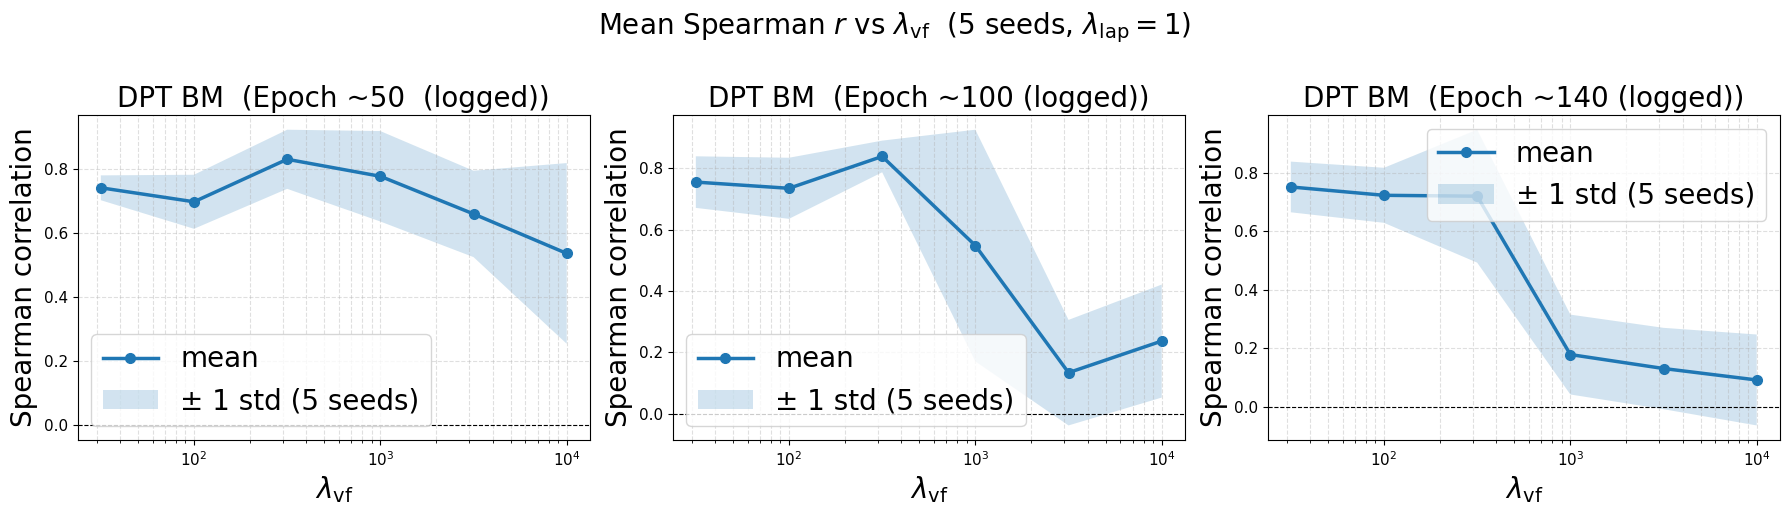

In [11]:
# ---------------------------------------------------------------------------
# Plot 1: Mean ± std across all 5 seeds — one panel per epoch checkpoint
# Matches the intended plot_correlation_vs_lambda_vf output
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50  (logged)',  axes[0]),
    ('~100', 'Epoch ~100 (logged)',  axes[1]),
    ('~140', 'Epoch ~140 (logged)',  axes[2]),
]

for label, title, ax in checkpoints:
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    line, = ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7, label='mean')
    band = ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2, label='± 1 std (5 seeds)')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=20)
    ax.set_ylabel('Spearman correlation', fontsize=20)
    ax.set_title(f'DPT BM  ({title})', fontsize=20)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=20)

plt.suptitle(
    r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (5 seeds, $\lambda_{\mathrm{lap}}=1$)',
    fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

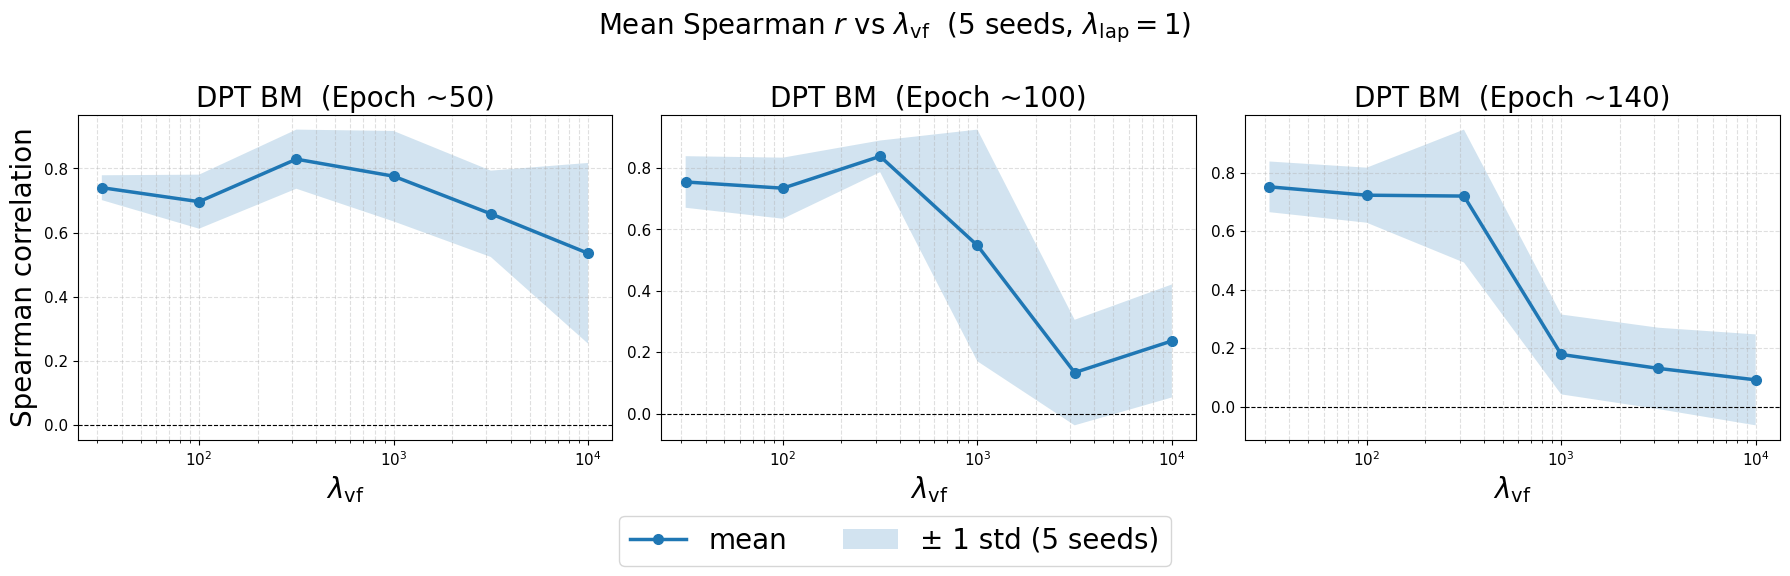

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

checkpoints = [
    ('~50',  'Epoch ~50',  axes[0]),
    ('~100', 'Epoch ~100',  axes[1]),
    ('~140', 'Epoch ~140',  axes[2]),
]

handles_for_legend = None

for i, (label, title, ax) in enumerate(checkpoints):
    mu  = summary[label]['mean']
    sig = summary[label]['std']
    line, = ax.semilogx(LAMBDA_VFS, mu, marker='o', linewidth=2.5, markersize=7, label='mean')
    band = ax.fill_between(LAMBDA_VFS, mu - sig, mu + sig, alpha=0.2, label='± 1 std (5 seeds)')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=20)
    ax.set_title(f'DPT BM  ({title})', fontsize=20)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=11)

    if i == 0:
        ax.set_ylabel('Spearman correlation', fontsize=20)
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()
    else:
        ax.set_ylabel('')

fig.legend(handles_for_legend, labels_for_legend, fontsize=20,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.12))

plt.suptitle(
    r'Mean Spearman $r$ vs $\lambda_{\mathrm{vf}}$  (5 seeds, $\lambda_{\mathrm{lap}}=1$)',
    fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('vf_sweep_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

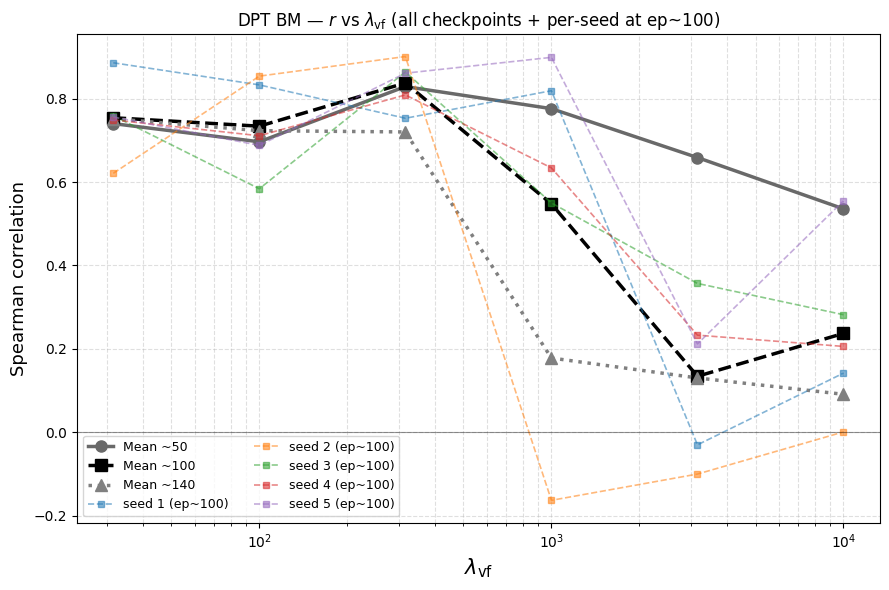

In [6]:
# ---------------------------------------------------------------------------
# Plot 2: Per-seed traces + mean — all three checkpoints overlaid
# ---------------------------------------------------------------------------

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
checkpoint_styles = {'~50': ('o', '-'), '~100': ('s', '--'), '~140': ('^', ':')}

fig, ax = plt.subplots(figsize=(9, 6))

grays = {'~50': 'dimgray', '~100': 'black', '~140': 'gray'}
for label, (marker, ls) in checkpoint_styles.items():
    mu = summary[label]['mean']
    ax.semilogx(LAMBDA_VFS, mu, marker=marker, linestyle=ls,
                linewidth=2.5, markersize=8, label=f'Mean {label}',
                color=grays[label])

# Individual seeds at epoch ~100
for s_idx, (color, slabel) in enumerate(zip(seed_colors, [f'seed {i}' for i in range(1, 6)])):
    vals = all_seeds[s_idx, :, EPOCH_IDX['~100']]
    ax.semilogx(LAMBDA_VFS, vals, marker='s', linestyle='--',
                linewidth=1.2, markersize=5, alpha=0.55, color=color, label=f'{slabel} (ep~100)')

ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Spearman correlation', fontsize=13)
ax.set_title(r'DPT BM — $r$ vs $\lambda_{\mathrm{vf}}$ (all checkpoints + per-seed at ep~100)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

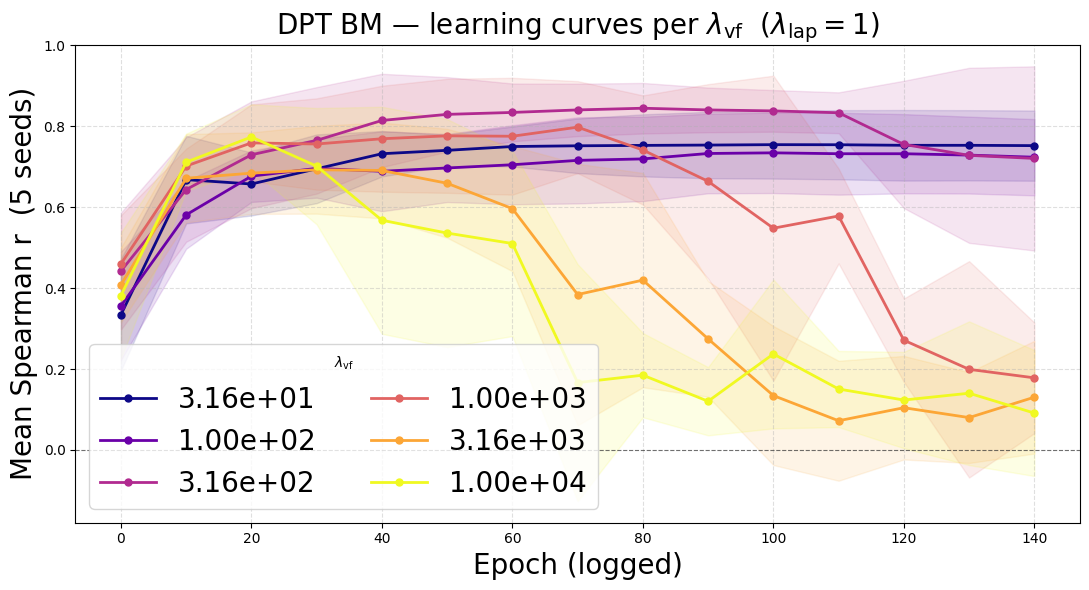

In [10]:
# ---------------------------------------------------------------------------
# Plot 3: Learning curves (r vs epoch) — mean across 5 seeds per λ_vf
# ---------------------------------------------------------------------------

epochs_arr = np.array(EPOCHS_LOGGED)
mean_curves = np.nanmean(all_seeds, axis=0)  # (6, 15)
std_curves  = np.nanstd(all_seeds, axis=0)

cmap = plt.cm.plasma
colors = [cmap(i / 5) for i in range(6)]

fig, ax = plt.subplots(figsize=(11, 6))
for lv_idx in range(6):
    lv_val = LAMBDA_VFS[lv_idx]
    mu = mean_curves[lv_idx]
    sig = std_curves[lv_idx]
    ax.plot(epochs_arr, mu, marker='o', markersize=5, linewidth=2.0,
            color=colors[lv_idx], label=f'{lv_val:.2e}')
    ax.fill_between(epochs_arr, mu - sig, mu + sig, alpha=0.12, color=colors[lv_idx])

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch (logged)', fontsize=20)
ax.set_ylabel('Mean Spearman r  (5 seeds)', fontsize=20)
ax.set_title(r'DPT BM — learning curves per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$)', fontsize=20)
ax.legend(title=r'$\lambda_{\mathrm{vf}}$', fontsize=20, ncol=2,
          loc='lower left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('vf_sweep_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

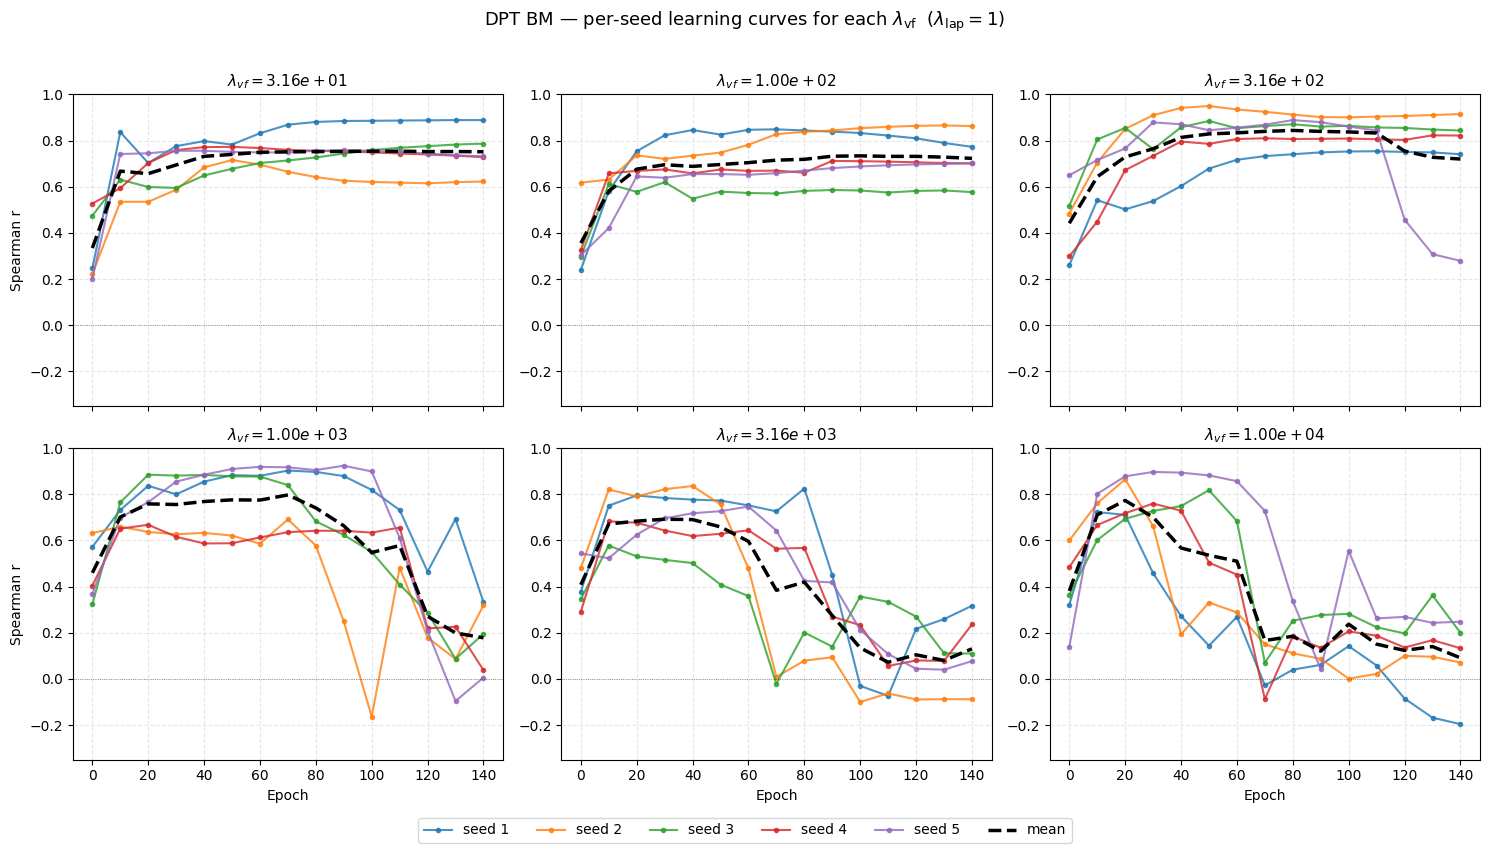

In [7]:
# ---------------------------------------------------------------------------
# Plot 4: Per-seed learning curves (small multiples) for each λ_vf
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

seed_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
seed_labels = [f'seed {i}' for i in range(1, 6)]

for lv_idx, ax in enumerate(axes.flat):
    lv_val = LAMBDA_VFS[lv_idx]
    for s_idx in range(5):
        ax.plot(epochs_arr, all_seeds[s_idx, lv_idx, :],
                marker='o', markersize=3, linewidth=1.5,
                color=seed_colors[s_idx], label=seed_labels[s_idx], alpha=0.8)
    # Mean
    ax.plot(epochs_arr, mean_curves[lv_idx],
            color='black', linewidth=2.5, linestyle='--', label='mean')
    ax.axhline(0, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(rf'$\lambda_{{vf}}={lv_val:.2e}$', fontsize=11)
    ax.set_ylim(-0.35, 1.0)
    ax.grid(True, linestyle='--', alpha=0.3)
    if lv_idx in (0, 3):
        ax.set_ylabel('Spearman r', fontsize=10)
    if lv_idx >= 3:
        ax.set_xlabel('Epoch', fontsize=10)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    r'DPT BM — per-seed learning curves for each $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$)',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vf_sweep_per_seed_grid.png', dpi=200, bbox_inches='tight')
plt.show()

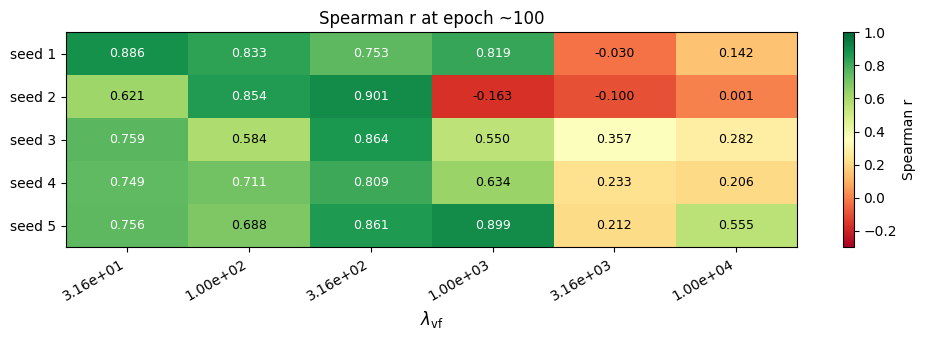

In [8]:
# ---------------------------------------------------------------------------
# Plot 5: Heatmap — r at epoch ~100 for all seeds × all λ_vf
# ---------------------------------------------------------------------------

r_ep100 = all_seeds[:, :, EPOCH_IDX['~100']]  # (5, 6)

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(r_ep100, aspect='auto', cmap='RdYlGn', vmin=-0.3, vmax=1.0)
ax.set_xticks(range(6))
ax.set_xticklabels([f'{v:.2e}' for v in LAMBDA_VFS], rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(5))
ax.set_yticklabels([f'seed {i}' for i in range(1, 6)])
ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=12)
ax.set_title('Spearman r at epoch ~100', fontsize=12)
plt.colorbar(im, ax=ax, label='Spearman r')

for i in range(5):
    for j in range(6):
        val = r_ep100[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                color='black' if abs(val) < 0.7 else 'white')

plt.tight_layout()
plt.savefig('vf_sweep_heatmap_ep100.png', dpi=200, bbox_inches='tight')
plt.show()

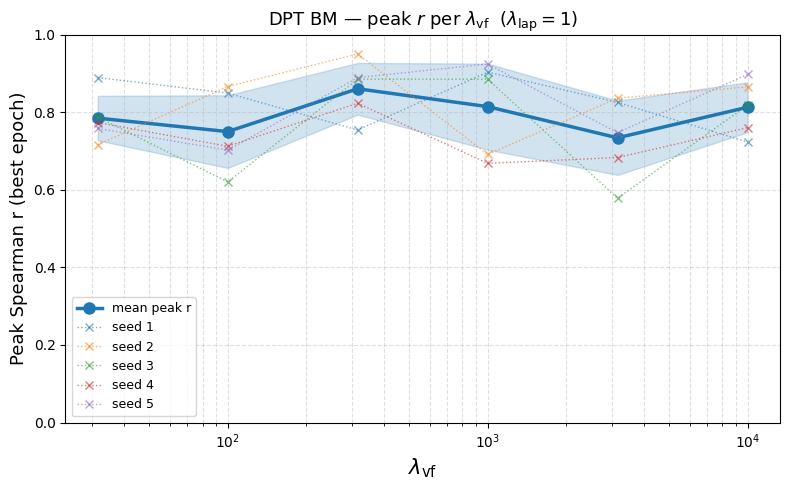

In [9]:
# ---------------------------------------------------------------------------
# Plot 6: Peak r achieved per (seed, lambda_vf) — shows best attainable r
# Useful since many runs diverge after their peak
# ---------------------------------------------------------------------------

peak_r = np.nanmax(all_seeds, axis=2)  # (5, 6) — max over epochs
mean_peak = peak_r.mean(axis=0)
std_peak  = peak_r.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(LAMBDA_VFS, mean_peak, marker='o', linewidth=2.5, markersize=8,
            color='tab:blue', label='mean peak r')
ax.fill_between(LAMBDA_VFS, mean_peak - std_peak, mean_peak + std_peak,
                alpha=0.2, color='tab:blue')

for s_idx, (color, slabel) in enumerate(zip(seed_colors, seed_labels)):
    ax.semilogx(LAMBDA_VFS, peak_r[s_idx], marker='x', linestyle=':',
                linewidth=1.0, markersize=6, alpha=0.6, color=color, label=slabel)

ax.set_xlabel(r'$\lambda_{\mathrm{vf}}$', fontsize=15)
ax.set_ylabel('Peak Spearman r (best epoch)', fontsize=13)
ax.set_title(r'DPT BM — peak $r$ per $\lambda_{\mathrm{vf}}$  ($\lambda_{\mathrm{lap}}=1$)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('vf_sweep_peak_r.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# ---------------------------------------------------------------------------
# Summary table — best λ_vf per checkpoint + peak r
# ---------------------------------------------------------------------------

print('Best lambda_vf by mean r (5 seeds):\n')
for label in ['~50', '~100', '~140']:
    mu = summary[label]['mean']
    best_idx = np.nanargmax(mu)
    print(f'  Epoch {label:5s}:  lambda_vf = {LAMBDA_VFS[best_idx]:.3e}  '
          f'→  mean r = {mu[best_idx]:.3f}  (std={summary[label]["std"][best_idx]:.3f})')

print()
best_peak_idx = np.argmax(mean_peak)
print(f'  Peak r:     lambda_vf = {LAMBDA_VFS[best_peak_idx]:.3e}  '
      f'→  mean peak r = {mean_peak[best_peak_idx]:.3f}  (std={std_peak[best_peak_idx]:.3f})')

print()
print(df_summary.to_string(index=False, float_format='{:.3f}'.format))

Best lambda_vf by mean r (5 seeds):

  Epoch ~50  :  lambda_vf = 3.162e+02  →  mean r = 0.829  (std=0.092)
  Epoch ~100 :  lambda_vf = 3.162e+02  →  mean r = 0.838  (std=0.051)
  Epoch ~140 :  lambda_vf = 3.162e+01  →  mean r = 0.752  (std=0.087)

  Peak r:     lambda_vf = 3.162e+02  →  mean peak r = 0.860  (std=0.067)

 lambda_vf  ep50_mean  ep50_std  ep100_mean  ep100_std  ep140_mean  ep140_std
    31.623      0.740     0.039       0.754      0.084       0.752      0.087
   100.000      0.697     0.084       0.734      0.099       0.723      0.094
   316.228      0.829     0.092       0.838      0.051       0.720      0.227
  1000.000      0.776     0.141       0.548      0.377       0.178      0.137
  3162.278      0.659     0.134       0.134      0.172       0.130      0.139
 10000.000      0.536     0.281       0.237      0.184       0.091      0.156
